# Figure 4 | Community context of S1 carriage

This notebook regenerates four panels from the finalized plot-ready source tables. It does not rerun the prediction, meta-analysis or FastSpar pipelines. Panels **a-d follow the four nonempty plotting cells in the supplied notebook**, in their original order. Historical panel labels in the source table filenames have been corrected when packaging the data.

Inputs are under `../data/figure4/`; exports are written to `../outputs/figure4/`. Run all cells from the repository root or the `notebooks/` directory. The original colours, dimensions, labels and plotting parameters are retained. SVG/PDF are vector exports; PNG/TIFF use 600 dpi. TIFF is uncompressed to avoid dependence on a platform-specific LZW encoder; its pixel data are unchanged. Arial is used where installed; Matplotlib may fall back to an available font on other systems.


## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Image as NotebookImage, display

# Run this notebook from either the repository root or its notebooks directory.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / "data" / "figure4"
OUTPUT_DIR = REPO_ROOT / "outputs" / "figure4"
assert DATA_DIR.is_dir(), "Run from the repository root or the notebooks directory."
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "core_ex": "#245B8A", "supported_ex": "#5B8DB8",
    "core_col": "#B44A3F", "supported_col": "#D48772",
    "neutral": "#A7ADB4", "null": "#8B93A7",
    "hgb": "#D8523C", "healthy": "#2F7F5F",
}


def save_pub_figure(fig, stem, width_mm, height_mm, dpi=600, tight=True):
    """Export SVG, PDF, PNG and uncompressed TIFF."""
    fig.set_size_inches(width_mm / 25.4, height_mm / 25.4)
    stem.parent.mkdir(parents=True, exist_ok=True)
    options = {"bbox_inches": "tight", "pad_inches": 0.03} if tight else {}
    fig.savefig(stem.with_suffix(".svg"), **options)
    fig.savefig(stem.with_suffix(".pdf"), **options)
    fig.savefig(stem.with_suffix(".png"), dpi=dpi, **options)
    fig.savefig(stem.with_suffix(".tiff"), dpi=dpi,
                pil_kwargs={"compression": "raw"}, **options)


def taxon_math_label(taxonomy_label, abbreviate=False):
    """Format species names in italics, optionally abbreviating the genus."""
    species = taxonomy_label.split(" (")[0]
    if abbreviate:
        parts = species.split(" ")
        if len(parts) >= 2:
            genus = parts[0].replace("s__", "")
            species = f"{genus[0]}. {parts[1]}"
    species = species.replace("_", r"\_").replace(" ", r"\ ")
    return rf"$\it{{{species}}}$"


def tier_color(tier, merge_supported=False):
    """Keep the source panel's tier-specific colour conventions."""
    return {
        "Core Co-excluder": COLORS["core_ex"],
        "Supported Co-excluder": COLORS["core_ex" if merge_supported else "supported_ex"],
        "Core Co-colonizer": COLORS["core_col"],
        "Supported Co-colonizer": COLORS["core_col" if merge_supported else "supported_col"],
    }.get(tier, COLORS["neutral"])


## Panel a | Prediction performance and permutation null

Inputs: `Figure4a_roc_curve.tsv`, `Figure4a_pr_curve.tsv`, `Figure4a_hgb_permutation_null.tsv` and `Figure4a_metric_annotations.tsv`. These are the source notebook's first plotting cell (historically labelled b). The finalized ROC/PR points, prevalence baseline and AUROC permutation results are used without recomputation.

meta NOT subset; don't know how to subset; dropped


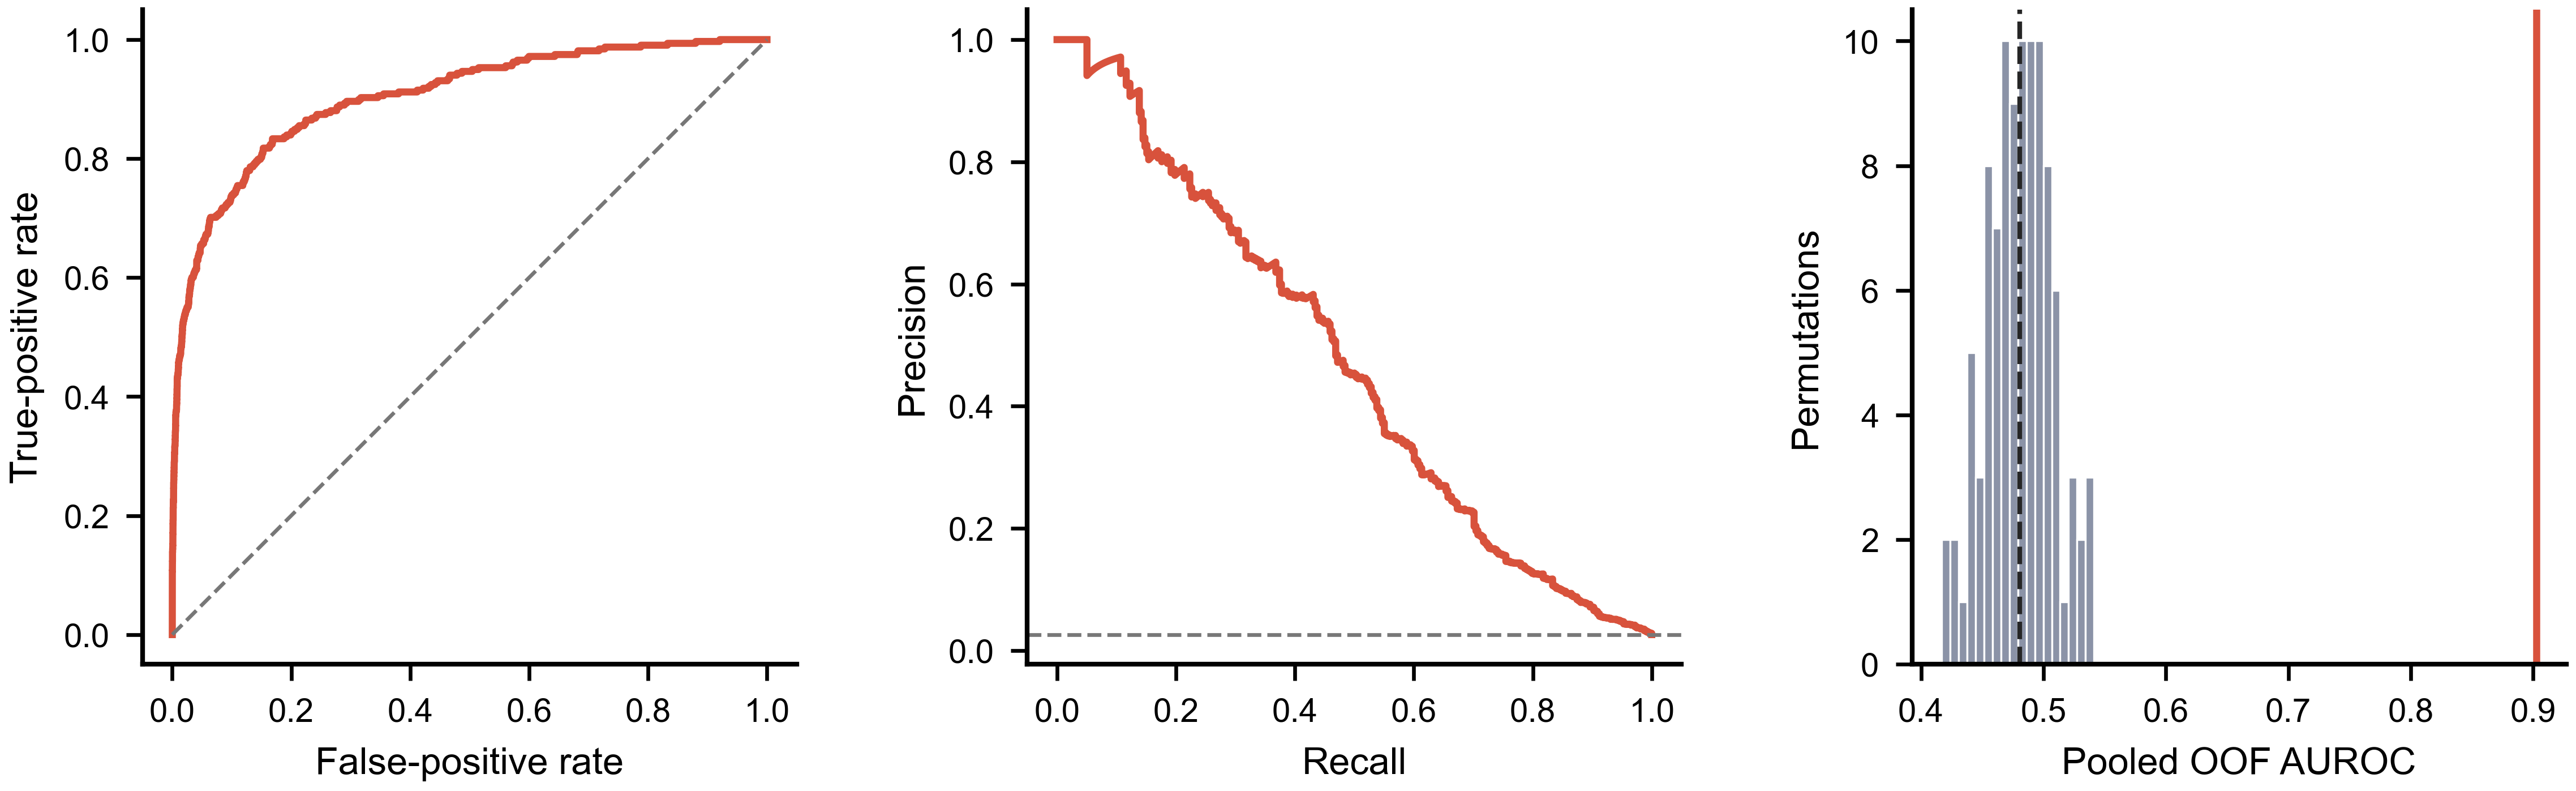

In [2]:
mpl.rcParams.update({
    "font.family": "Arial", "font.size": 7, "axes.labelsize": 8,
    "axes.titlesize": 8.5, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "axes.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "none", "pdf.fonttype": 42,
})

roc_data = pd.read_csv(DATA_DIR / "Figure4a_roc_curve.tsv", sep="\t")
pr_data = pd.read_csv(DATA_DIR / "Figure4a_pr_curve.tsv", sep="\t")
null = pd.read_csv(DATA_DIR / "Figure4a_hgb_permutation_null.tsv", sep="\t")
ann = pd.read_csv(DATA_DIR / "Figure4a_metric_annotations.tsv", sep="\t").iloc[0]

fig, axes = plt.subplots(1, 3)
axes[0].plot(roc_data.fpr, roc_data.tpr, color=COLORS["hgb"], lw=1.5)
axes[0].plot([0, 1], [0, 1], color="#777777", lw=0.8, ls="--")
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate")
axes[1].plot(pr_data.recall, pr_data.precision, color=COLORS["hgb"], lw=1.5)
axes[1].axhline(ann.primary_baseline_prevalence, color="#777777", lw=0.8, ls="--")
axes[1].set(xlabel="Recall", ylabel="Precision")
axes[2].hist(null.null_auroc, bins=18, color=COLORS["null"],
             edgecolor="white", linewidth=0.4)
axes[2].axvline(ann.observed_auroc, color=COLORS["hgb"], lw=1.5)
axes[2].axvline(ann.null_auroc_mean, color="#252525", lw=1.0, ls="--")
axes[2].set(xlabel="Pooled OOF AUROC", ylabel="Permutations")
for ax in axes:
    ax.set_box_aspect(1)
fig.tight_layout(w_pad=1.4)
save_pub_figure(fig, OUTPUT_DIR / "Figure4a_panel", 200, 80)
plt.close(fig)
display(NotebookImage(filename=str(OUTPUT_DIR / "Figure4a_panel.png")))


## Panel b | Adjusted pooled associations

Input: `Figure4b_adjusted_meta_associations.tsv`. This is the source notebook's second plotting cell (historically labelled c). The plotted values are pooled CLR coefficients and their 95% confidence intervals. Core and supported candidates share the source panel's blue/red colours.

meta NOT subset; don't know how to subset; dropped


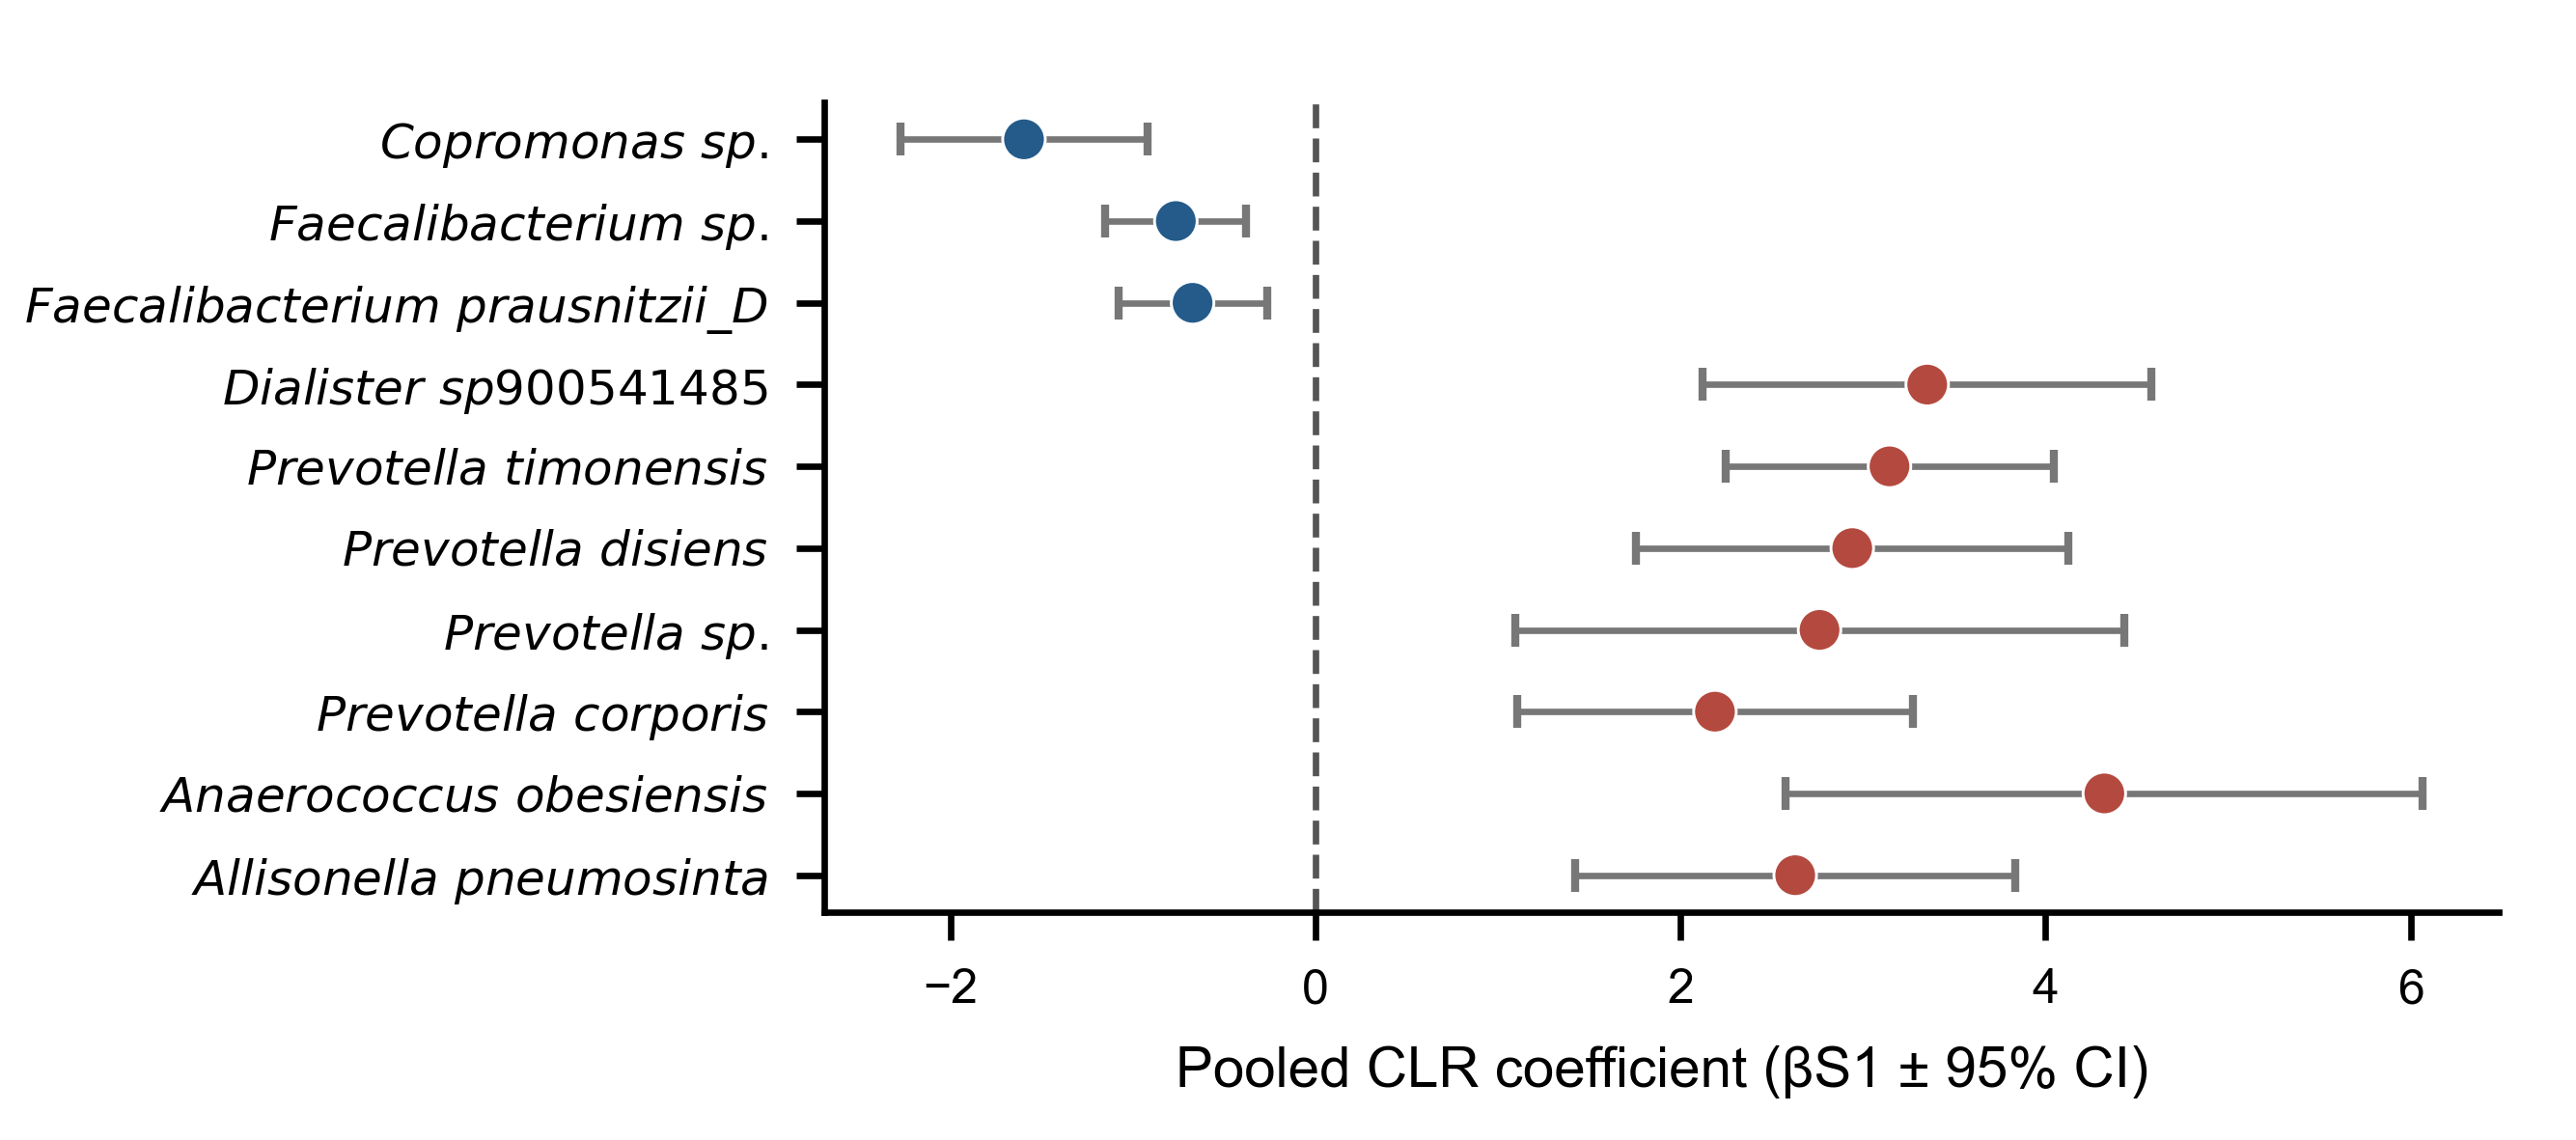

In [3]:
mpl.rcParams.update({
    "font.family": "Arial", "font.size": 6, "axes.labelsize": 7,
    "axes.titlesize": 7.5, "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 7, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "none", "pdf.fonttype": 42,
})

data = pd.read_csv(DATA_DIR / "Figure4b_adjusted_meta_associations.tsv", sep="\t")
width_mm, height_mm = 113, 50
fig, ax = plt.subplots(figsize=(width_mm / 25.4, height_mm / 25.4))
y = np.arange(len(data))
colors = [tier_color(t, merge_supported=True) for t in data.tier]
ax.errorbar(data.pooled_beta, y,
            xerr=[data.pooled_beta - data.ci_low, data.ci_high - data.pooled_beta],
            fmt="none", ecolor="#777777", lw=0.8, capsize=2)
ax.scatter(data.pooled_beta, y, c=colors, s=28, zorder=3,
           edgecolor="white", linewidth=0.35)
ax.axvline(0, color="#555555", lw=0.8, ls="--")
ax.set_yticks(y)
ax.set_yticklabels([taxon_math_label(r.final_taxonomy_label) for _, r in data.iterrows()])
ax.invert_yaxis()
ax.set_xlabel("Pooled CLR coefficient (βS1 ± 95% CI)")
# Preserve fixed canvas dimensions and manual margins from the source cell.
fig.subplots_adjust(left=0.32, right=0.97, top=0.91, bottom=0.20)
save_pub_figure(fig, OUTPUT_DIR / "Figure4b_panel", width_mm, height_mm, tight=False)
plt.close(fig)
display(NotebookImage(filename=str(OUTPUT_DIR / "Figure4b_panel.png")))


## Panel c | Reproducibility across studies

Input: `Figure4c_cross_study_reproducibility.tsv`. This is the source notebook's third plotting cell (historically labelled d). Columns contain candidate taxa; rows contain study identifiers and the pooled estimate. Missing estimates remain masked, and the source's 95th-percentile colour limit is retained.

meta NOT subset; don't know how to subset; dropped


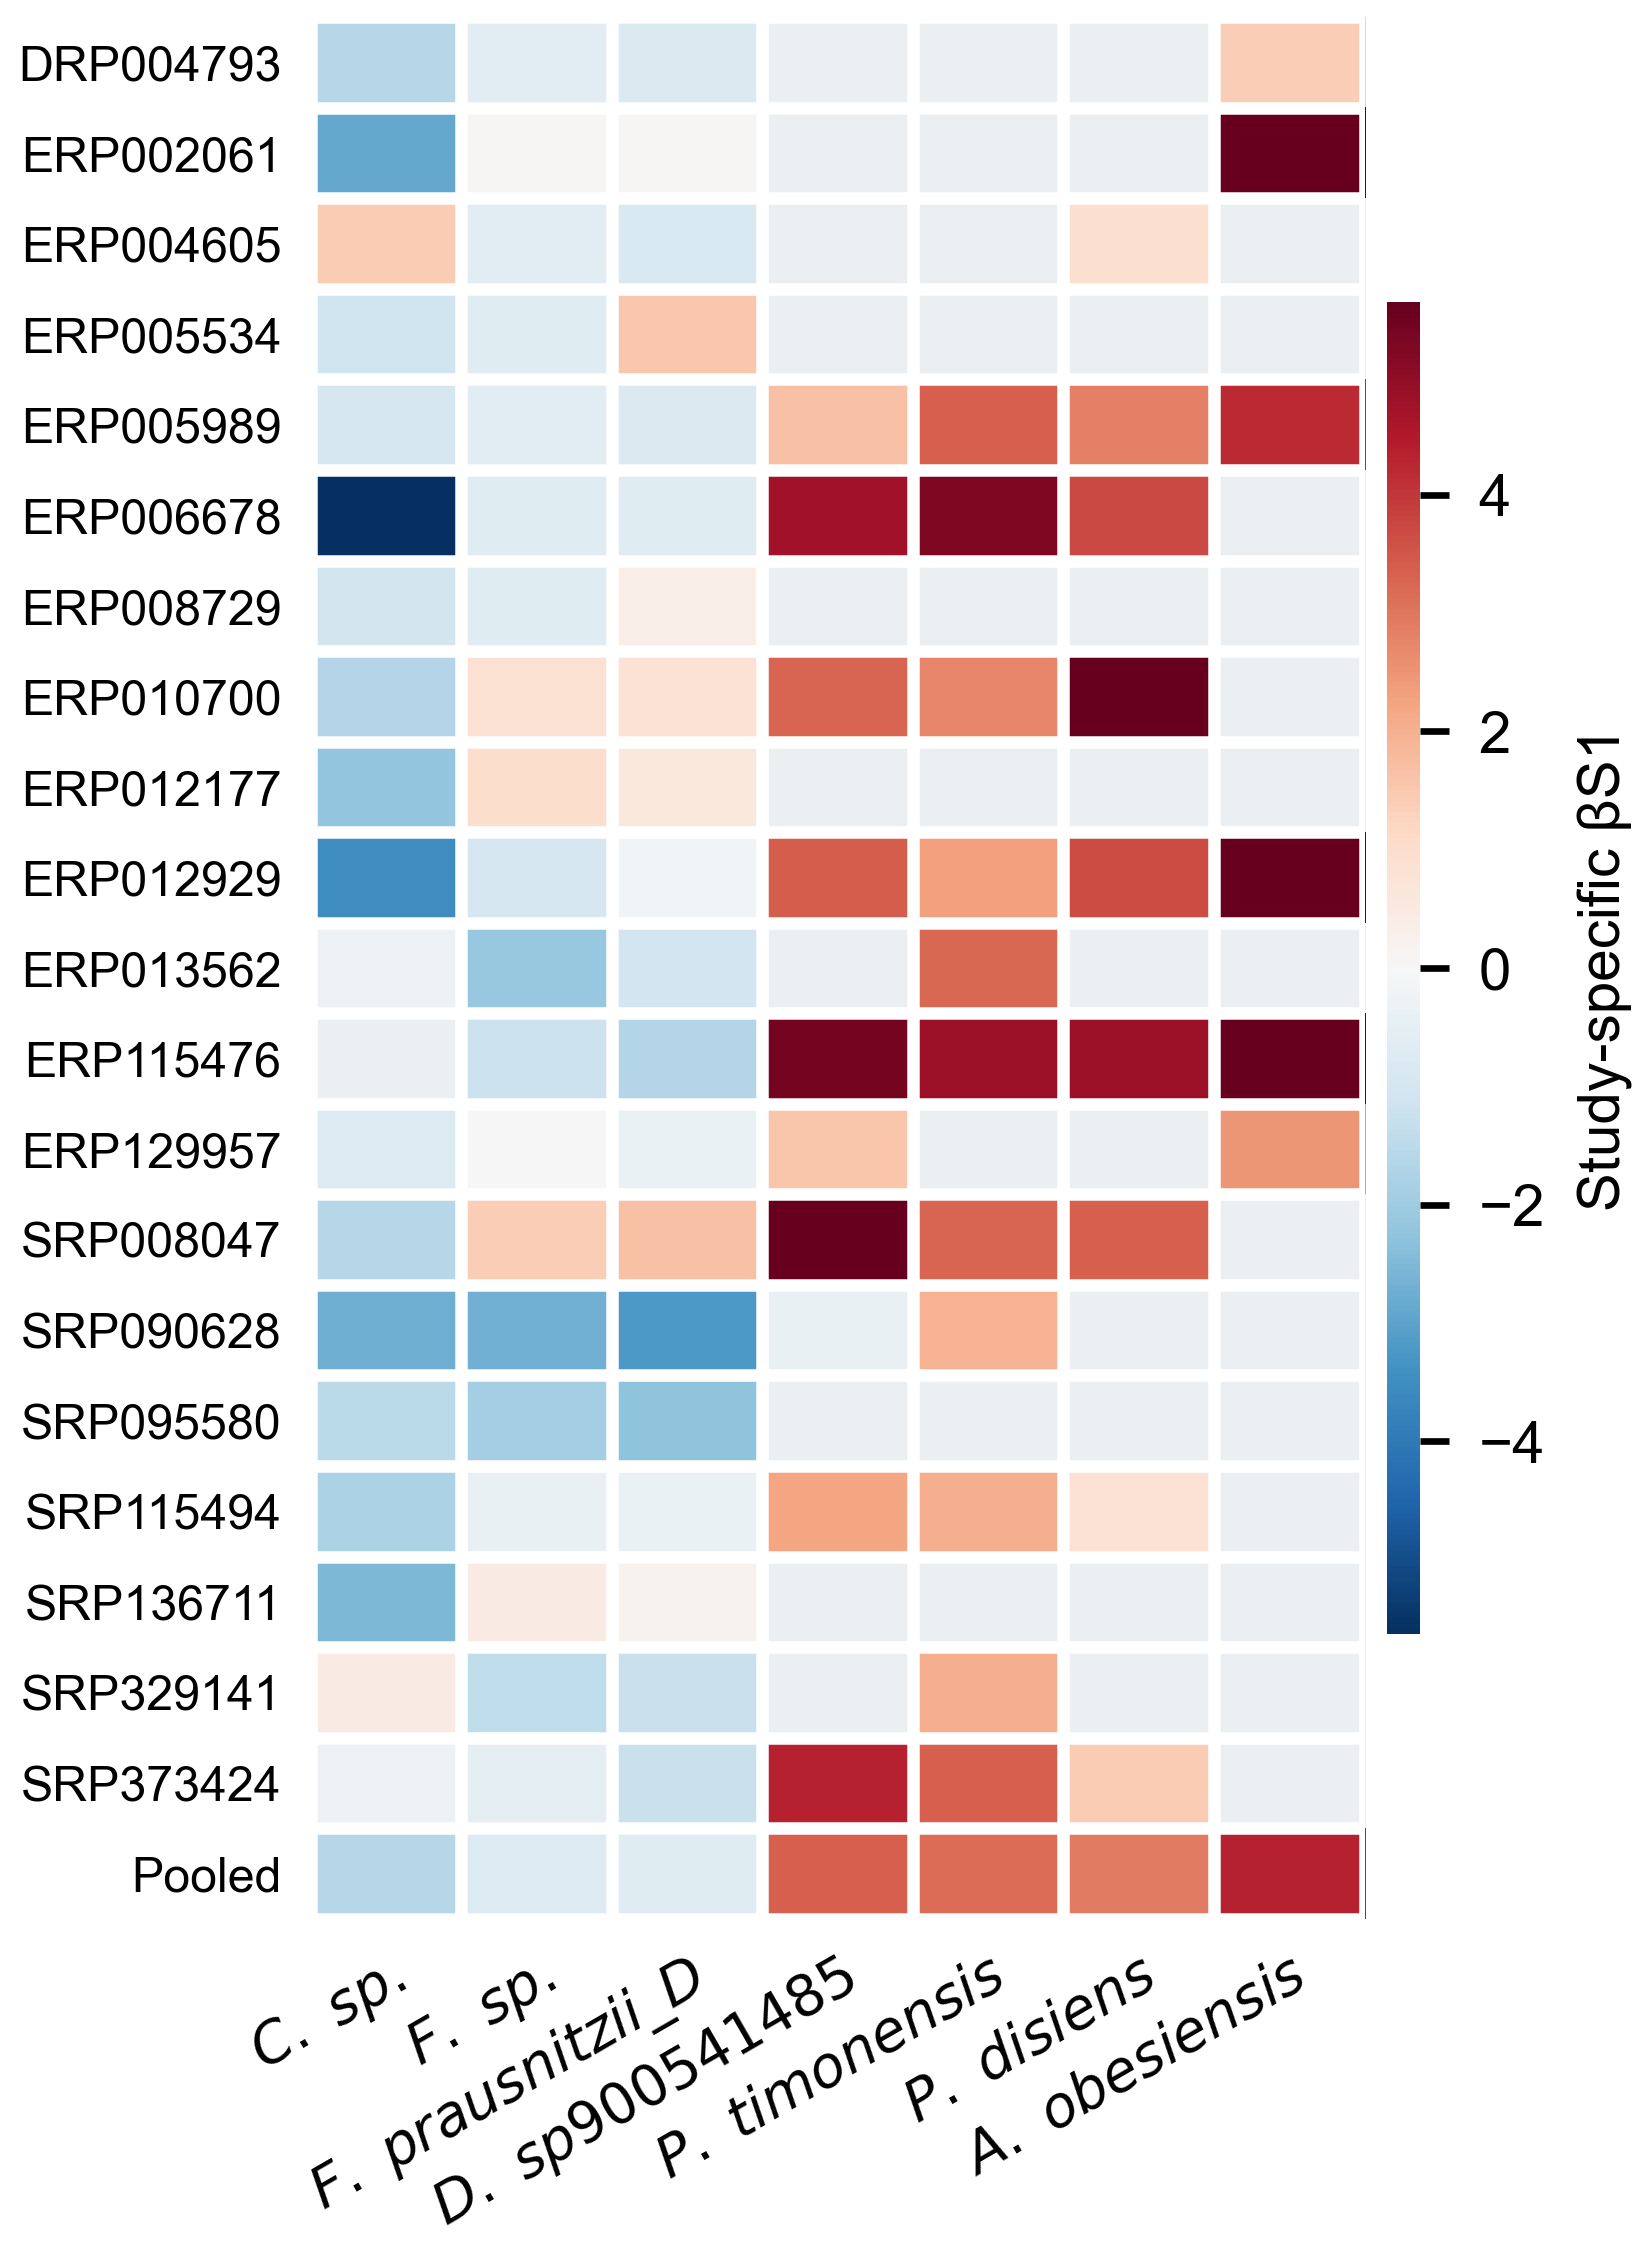

In [4]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 7, "axes.labelsize": 8, "axes.titlesize": 8.5,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "none", "pdf.fonttype": 42,
})

data = pd.read_csv(DATA_DIR / "Figure4c_cross_study_reproducibility.tsv", sep="\t")
order = data[["genome_id", "final_taxonomy_label", "tier", "meta_beta", "sign_concordance"]].drop_duplicates().reset_index(drop=True)
study_order = sorted(data.study.dropna().unique())
pivot = data.pivot_table(index="genome_id", columns="study", values="beta_s1",
                        aggfunc="first").reindex(index=order.genome_id, columns=study_order)
pivot["Pooled"] = order.set_index("genome_id").loc[pivot.index, "meta_beta"]

fig, ax = plt.subplots()
cmap = mpl.colormaps["RdBu_r"].copy()
cmap.set_bad("#ECEFF2")
vmax = max(1.0, float(np.nanpercentile(np.abs(pivot.to_numpy()), 95)))
image = ax.imshow(np.ma.masked_invalid(pivot.to_numpy().T), aspect="auto",
                  cmap=cmap, vmin=-vmax, vmax=vmax)
# White minor grid lines separate adjacent heatmap cells.
ax.set_xticks(np.arange(len(order) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(pivot.columns) + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(len(order)))
labels = [taxon_math_label(r.final_taxonomy_label, abbreviate=True)
          for _, r in order.iterrows()]
ax.set_xticklabels(labels, rotation=30, ha="right", rotation_mode="anchor", fontsize=6.8)
ax.set_yticks(np.arange(len(pivot.columns)))
ax.set_yticklabels(pivot.columns, fontsize=5.8)
ax.tick_params(which="major", length=0)
bar = fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02,
                   orientation="vertical", shrink=0.95, aspect=40)
bar.set_label("Study-specific βS1", fontsize=7)
bar.outline.set_visible(False)
fig.subplots_adjust(left=0.15, right=0.92, top=0.95, bottom=0.25)
save_pub_figure(fig, OUTPUT_DIR / "Figure4c_panel", 61, 115)
plt.close(fig)
display(NotebookImage(filename=str(OUTPUT_DIR / "Figure4c_panel.png")))


## Panel d | FastSpar correlations across contexts

Input: `Figure4d_fastspar_contexts.tsv`. This is the source notebook's fourth plotting cell (historically labelled e). Context labels (`Full`, `Healthy`, `G2`, `all14`), candidate tiers and correlation values are retained exactly as supplied. Negative correlations identify candidate co-excluders, not experimentally established antagonists.

meta NOT subset; don't know how to subset; dropped


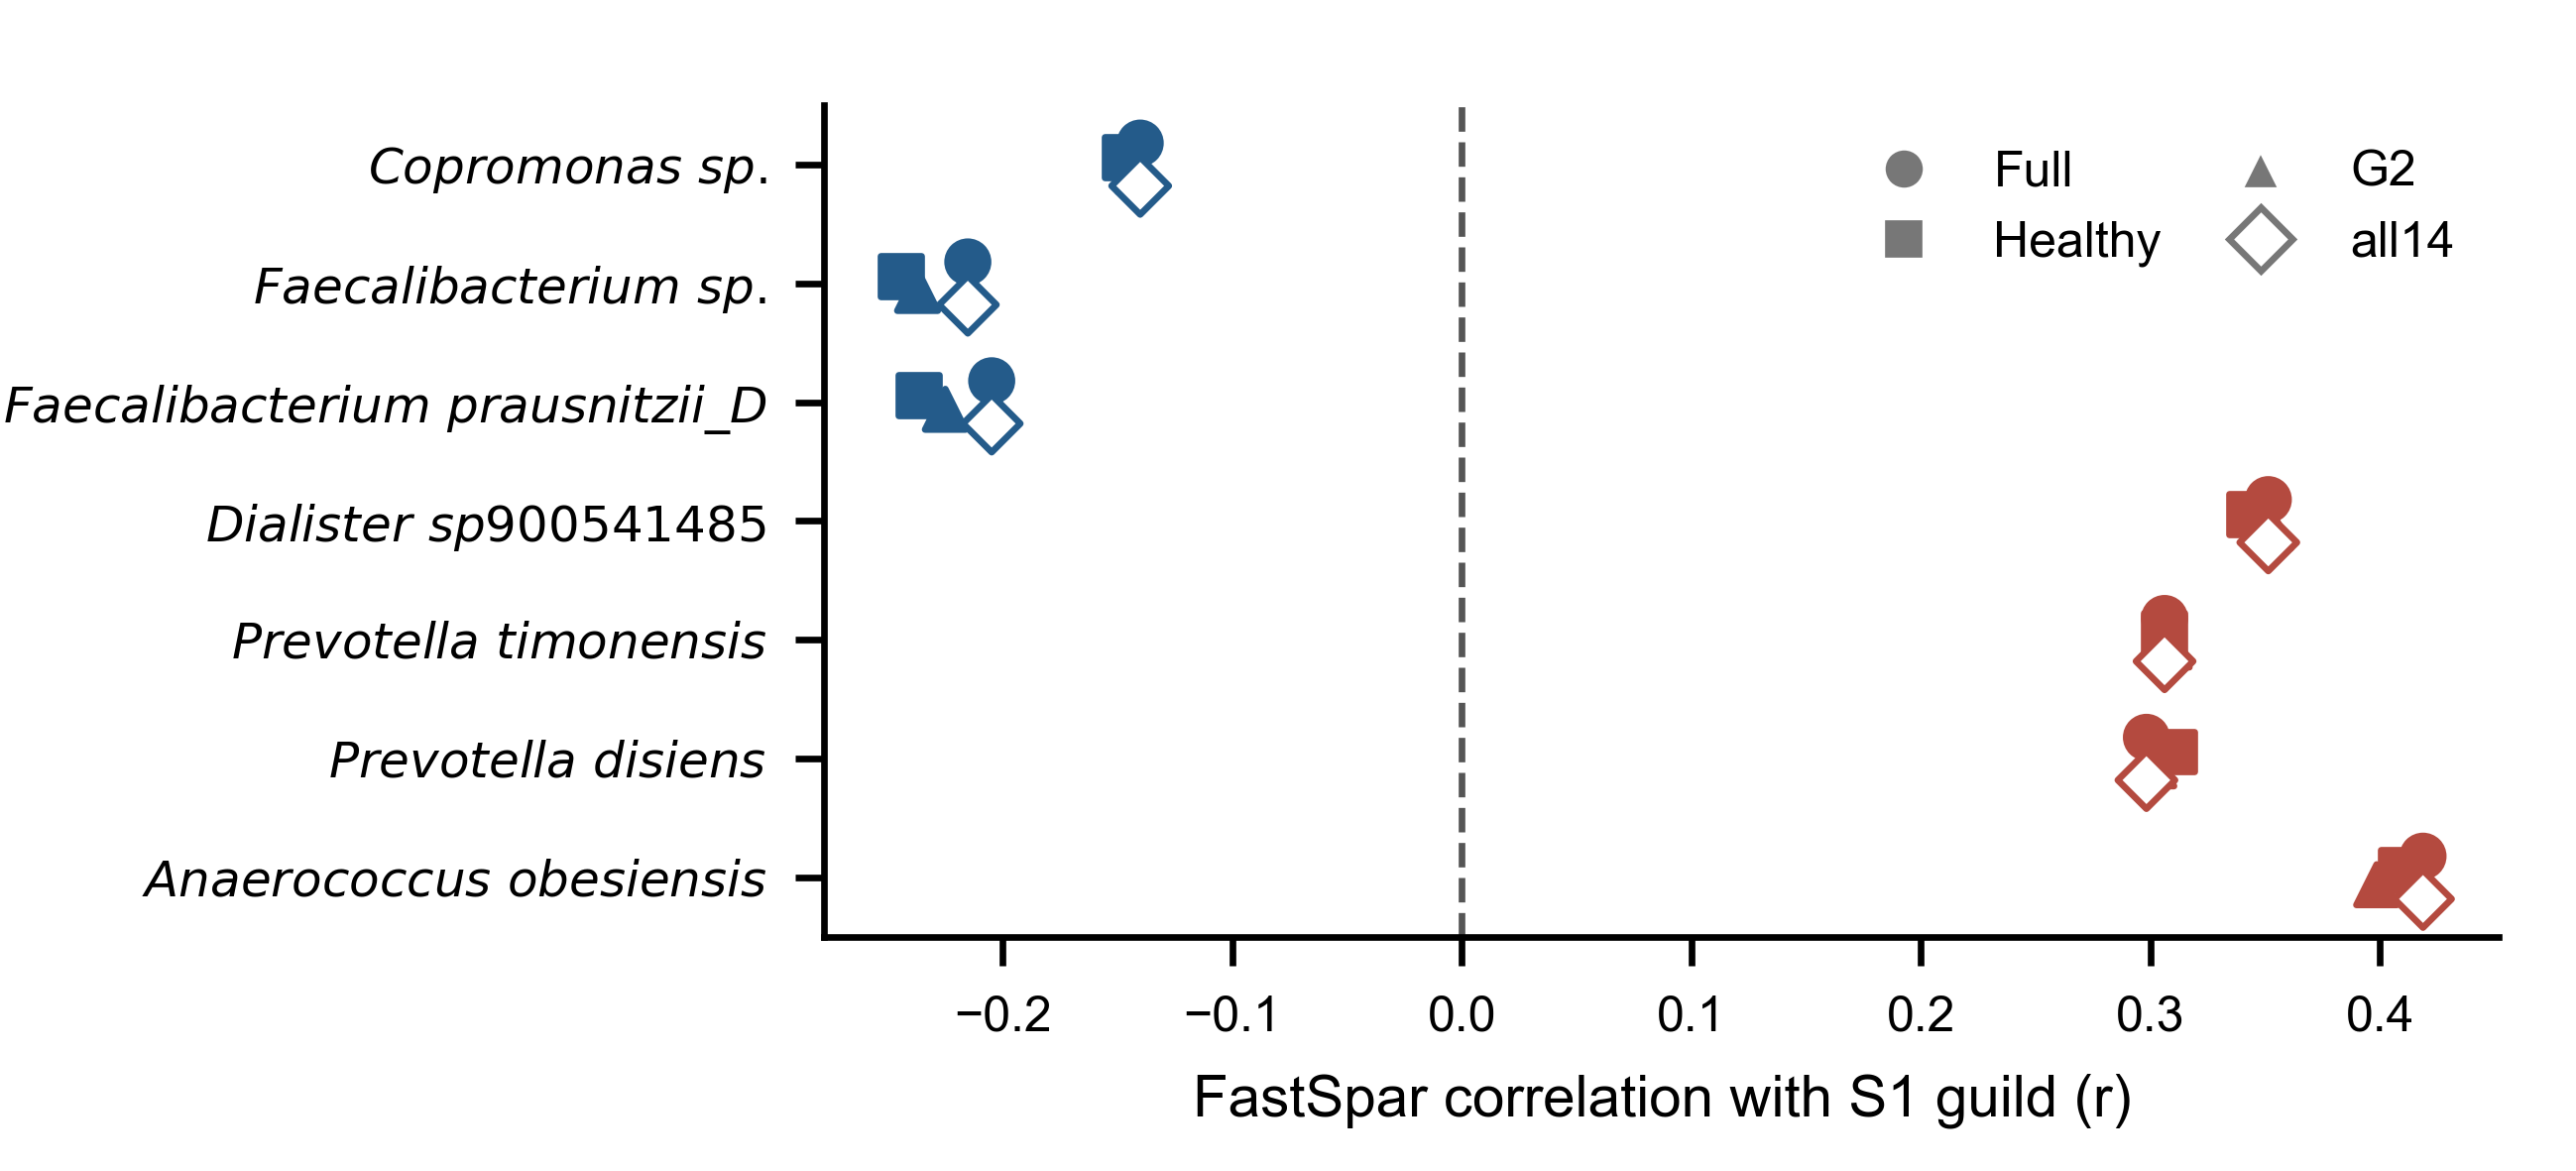

In [5]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7.5,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "none", "pdf.fonttype": 42,
})

data = pd.read_csv(DATA_DIR / "Figure4d_fastspar_contexts.tsv", sep="\t")
taxa = data[["genome_id", "final_taxonomy_label", "tier"]].drop_duplicates().reset_index(drop=True)
contexts = ["Full", "Healthy", "G2", "all14"]
markers = {"Full": "o", "Healthy": "s", "G2": "^", "all14": "D"}
width_mm, height_mm = 110, 50
fig, ax = plt.subplots(figsize=(width_mm / 25.4, height_mm / 25.4))
for j, context in enumerate(contexts):
    sub = data[data.context == context].set_index("genome_id").loc[taxa.genome_id]
    colors = [tier_color(t, merge_supported=True) for t in taxa.tier]
    ax.scatter(sub.fastspar_r, np.arange(len(taxa)) + (j - 1.5) * 0.12,
               s=24, marker=markers[context],
               facecolors="white" if context == "all14" else colors,
               edgecolors=colors, linewidths=0.8)
ax.axvline(0, color="#555555", lw=0.8, ls="--")
ax.set_yticks(np.arange(len(taxa)))
ax.set_yticklabels([taxon_math_label(r.final_taxonomy_label) for _, r in taxa.iterrows()])
ax.invert_yaxis()
ax.set_xlabel("FastSpar correlation with S1 guild (r)")
# Contexts use marker shape; candidate tiers retain their source colours.
legend_elements = [
    Line2D([0], [0], marker=markers["Full"], color="w", markerfacecolor="#777777", markersize=5.5, label="Full"),
    Line2D([0], [0], marker=markers["Healthy"], color="w", markerfacecolor="#777777", markersize=5.5, label="Healthy"),
    Line2D([0], [0], marker=markers["G2"], color="w", markerfacecolor="#777777", markersize=5.5, label="G2"),
    Line2D([0], [0], marker=markers["all14"], color="w", markeredgecolor="#777777", markerfacecolor="white", markeredgewidth=0.8, markersize=5.5, label="all14"),
]
ax.legend(handles=legend_elements, ncol=2, loc="upper right", frameon=False, columnspacing=1.0)
fig.subplots_adjust(left=0.32, right=0.97, top=0.91, bottom=0.20)
save_pub_figure(fig, OUTPUT_DIR / "Figure4d_panel", width_mm, height_mm, tight=False)
plt.close(fig)
display(NotebookImage(filename=str(OUTPUT_DIR / "Figure4d_panel.png")))
